## Imports 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Carregar dados

In [4]:
df =pd.read_csv("compras_mes.csv", sep=";")
df.head()

,gasto,frequencia
0,128.940855,2
1,117.511243,3
2,131.658394,4
3,147.414537,1
4,115.785239,3


## Exploração Estatistica

In [5]:
print("Resumo estatistio")
print(df.describe())
print("\nCorrelação")
print(df.corr())


Resumo estatistio
             gasto  frequencia
count   150.000000  150.000000
mean    463.810834   10.226667
std     322.266413    7.014986
min      84.725938    0.000000
25%     126.329488    4.000000
50%     408.049854    9.000000
75%     754.228621   15.000000
max    1129.199874   28.000000

Correlação
               gasto  frequencia
gasto       1.000000    0.837255
frequencia  0.837255    1.000000


## Fitar

In [6]:
df =df[df["frequencia"] != 0]
print("Frequecia")
print(df.describe())

Frequecia
             gasto  frequencia
count   147.000000  147.000000
mean    471.080073   10.435374
std     321.445568    6.930247
min      84.725938    1.000000
25%     129.353468    4.000000
50%     412.987515    9.000000
75%     764.072702   15.000000
max    1129.199874   28.000000


## Vizualizar os dados

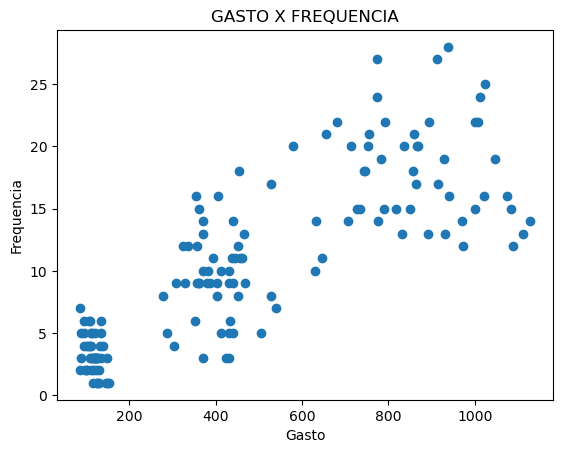

In [7]:
plt.scatter(df["gasto"], df["frequencia"])
plt.xlabel("Gasto")
plt.ylabel("Frequencia")
plt.title("GASTO X FREQUENCIA")
plt.show()

## Padronização dos dados

In [8]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(df)

## Metodo do cotovelo

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

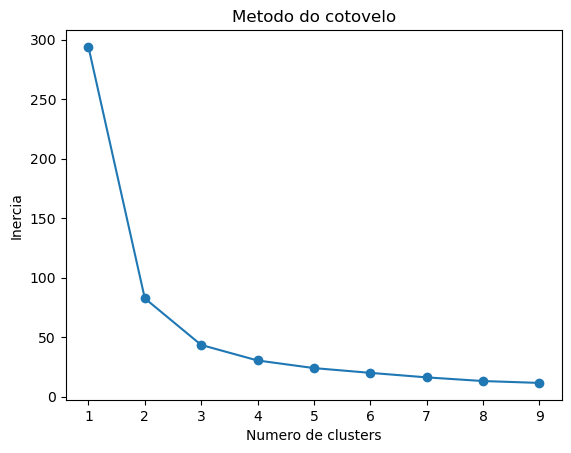

In [15]:
inersia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(x_scaler)
    inersia.append(kmeans.inertia_)

plt.plot(k_range, inersia, marker='o')
plt.xlabel("Numero de clusters")
plt.ylabel("Inercia")
plt.title("Metodo do cotovelo")
plt.show()

## Aplicação do kmeans

In [16]:
kmeans = KMeans(n_clusters = k, random_state = 42)
df["cluster"] = kmeans.fit_predict(x_scaler)

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


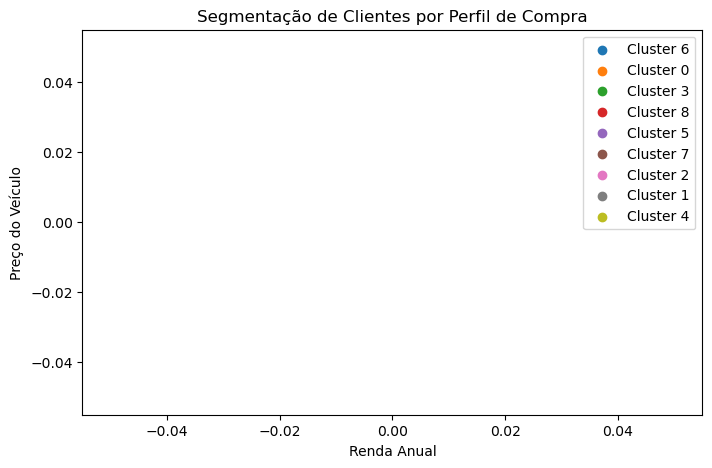

In [17]:
# plt.figure()

# for cluster in df["cluster"].unique():
#     subset = df =df[df["cluster"] == cluster]
#     plt.scatter(subset['gasto'],subset["frequencia"],label=f"Cluster {cluster}")
    
# plt.xlabel("Renda Anual")
# plt.ylabel("Preço do Veículo")
# plt.title("Segmentação de Clientes por Perfil de Compra")
# plt.legend()
# plt.show()


plt.figure(figsize=(8,5))

for cluster in df["cluster"].unique():
    subset = df[df["cluster"] == cluster]
    plt.scatter(subset["gasto"], subset["frequencia"], label=f"Cluster {cluster}")

plt.xlabel("Renda Anual")
plt.ylabel("Preço do Veículo")
plt.title("Segmentação de Clientes por Perfil de Compra")
plt.legend()
plt.show()
